Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



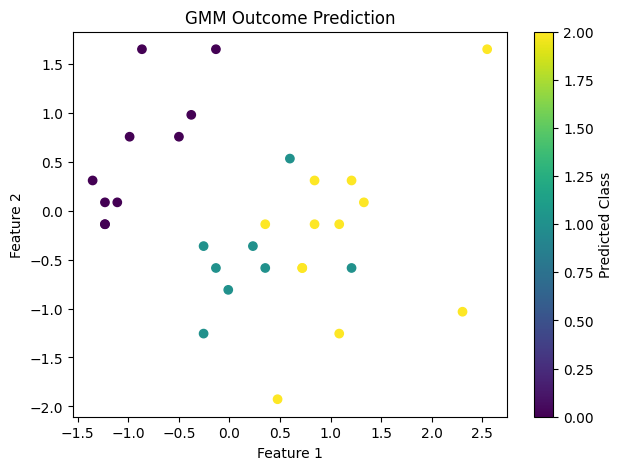

In [1]:
# Experiment 3: Gaussian Mixture Model for Outcome Prediction

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import mode

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)

# Train model
gmm.fit(X_train_scaled)

# Predict cluster labels
train_clusters = gmm.predict(X_train_scaled)
test_clusters = gmm.predict(X_test_scaled)

# Convert cluster labels to actual class labels
cluster_to_class = {}

for cluster in range(3):
    labels = y_train[train_clusters == cluster]
    cluster_to_class[cluster] = mode(labels, keepdims=True).mode[0]

# Final predictions
y_pred = np.array([cluster_to_class[cluster] for cluster in test_clusters])

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize using first two features
plt.figure(figsize=(7, 5))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred, cmap="viridis")
plt.title("GMM Outcome Prediction")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Predicted Class")
plt.show()
